### Import Libraries

In [55]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# PART A : Image Feature Extraction and Classification

In [56]:
# A.1 Load images and inspect basic properties

CRACK_DIR     = "data/asphalt/Cracks"
NONCRACK_DIR  = "data/asphalt/NonCracks"

# Take all image filenames from each folder
crack_files    = os.listdir(CRACK_DIR)
noncrack_files = os.listdir(NONCRACK_DIR)

print("Crack images   :", len(crack_files))
print("Non-crack images:", len(noncrack_files))

# Peek at the first image of each class
sample_crack    = cv2.imread(os.path.join(CRACK_DIR, crack_files[0]))
sample_noncrack = cv2.imread(os.path.join(NONCRACK_DIR, noncrack_files[0]))

print("\nCrack sample shape    :", sample_crack.shape)
print("Non-crack sample shape:", sample_noncrack.shape)

Crack images   : 200
Non-crack images: 200

Crack sample shape    : (448, 448, 3)
Non-crack sample shape: (448, 448, 3)


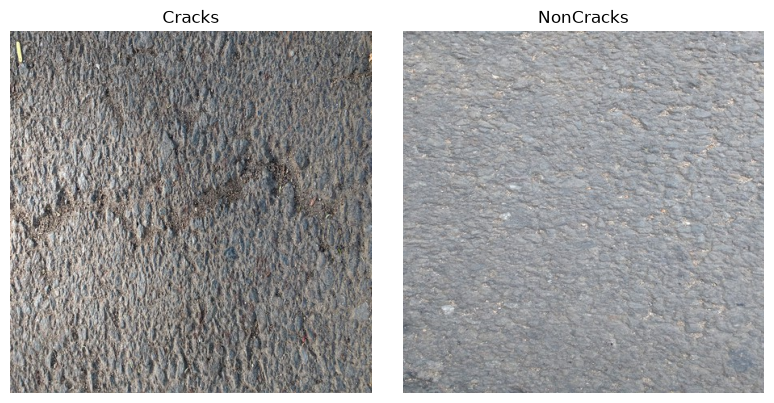

In [57]:
# A.1b Show one sample from each class

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

# OpenCV loads BGR, matplotlib wants RGB - convert for display only
ax[0].imshow(cv2.cvtColor(sample_crack, cv2.COLOR_BGR2RGB))
ax[0].set_title("Cracks")
ax[0].axis("off")

ax[1].imshow(cv2.cvtColor(sample_noncrack, cv2.COLOR_BGR2RGB))
ax[1].set_title("NonCracks")
ax[1].axis("off")

plt.tight_layout()
plt.show()

In [58]:
# A.2 Verify sizes, convert to grayscale, store as arrays

# We need a fixed-size, single-channel representation for
# every image before we can extract one feature row per image.


def load_grayscale(folder, label):
    """Read every image in `folder`, convert to grayscale, return (images, labels)."""
    images, labels = [], []
    for fname in os.listdir(folder):
        path = os.path.join(folder, fname)
        img = cv2.imread(path)                    # BGR
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # single channel
        images.append(gray)
        labels.append(label)
    return images, labels

# Load both classes
crack_imgs, crack_lbls       = load_grayscale(CRACK_DIR, 1)
noncrack_imgs, noncrack_lbls = load_grayscale(NONCRACK_DIR, 0)

# Combine into one list
all_images = crack_imgs + noncrack_imgs
all_labels = crack_lbls + noncrack_lbls

# Verify every image has the same shape
shapes = set(img.shape for img in all_images)
print("Unique shapes across all images:", shapes)

# Stack into a single 3-D NumPy array
# Shape will be (N, H, W) = (400, 448, 448)
X_images = np.stack(all_images, axis=0)
y = np.array(all_labels)

print("Feature image array shape:", X_images.shape)
print("Label array shape       :", y.shape)
print("Pixel value range       :", X_images.min(), "to", X_images.max())

Unique shapes across all images: {(448, 448)}
Feature image array shape: (400, 448, 448)
Label array shape       : (400,)
Pixel value range       : 0 to 255


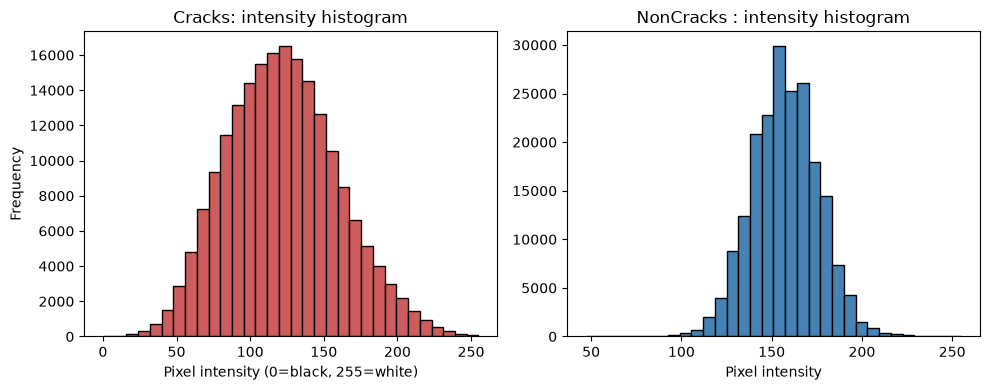

In [59]:
# A.2b Compare intensity histograms of the two classes

# "Dark pixel" and "bright pixel" ratios need thresholds.
# The histogram tells us where the bulk of pixels live, so we
# don't pick arbitrary numbers like 50 or 200.

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Cracks: pick the first crack image (index 0)
axes[0].hist(X_images[0].ravel(), bins=32, color="indianred", edgecolor="black")
axes[0].set_title("Cracks: intensity histogram")
axes[0].set_xlabel("Pixel intensity (0=black, 255=white)")
axes[0].set_ylabel("Frequency")

# NonCracks: first non-crack image (index 200 since first 200 are cracks)
axes[1].hist(X_images[200].ravel(), bins=32, color="steelblue", edgecolor="black")
axes[1].set_title("NonCracks : intensity histogram")
axes[1].set_xlabel("Pixel intensity")

plt.tight_layout()
plt.show()

In [60]:
# A.3 : Extract intensity-based features from every image

# Cracks = dark + high-variance texture.
# Non-cracks = uniform bright asphalt.
# So we quantify: brightness, spread, dark/bright tails.


DARK_THRESH   = 100   # justified by histogram: non-cracks have ~0 pixels below this
BRIGHT_THRESH = 190   # upper-tail threshold shared by both classes

def intensity_features(img):
    """
    img: 2-D uint8 grayscale array (H, W).
    Returns a 1-D feature vector (length 7).
    """
    pixels = img.ravel().astype(np.float32)

    mean_brightness = pixels.mean()
    contrast        = pixels.std()
    dark_ratio      = (pixels < DARK_THRESH).mean()      # fraction very dark
    bright_ratio    = (pixels > BRIGHT_THRESH).mean()    # fraction very bright
    median          = np.median(pixels)
    p10             = np.percentile(pixels, 10)          # dark tail
    p90             = np.percentile(pixels, 90)          # bright tail

    return np.array([mean_brightness, contrast, dark_ratio,
        bright_ratio, median, p10, p90], dtype=np.float32)

# Apply to every image → matrix of shape (400, 7)
X_intensity = np.stack([intensity_features(img) for img in X_images], axis=0)

print("Intensity feature matrix shape:", X_intensity.shape)
print("\nFirst 3 rows (Cracks, then NonCracks):")
print(X_intensity[:3])

# Quick class-wise averages
crack_feats    = X_intensity[y == 1].mean(axis=0)
noncrack_feats = X_intensity[y == 0].mean(axis=0)

names = ["mean_bright", "contrast", "dark_ratio",
    "bright_ratio", "median", "p10", "p90"]

print("\nFeature           | Cracks   | NonCracks | Separated?")
print("-" * 55)
for n, c, nc in zip(names, crack_feats, noncrack_feats):
    gap = abs(c - nc)
    print(f"{n:18s}| {c:8.3f} | {nc:9.3f} | {gap:.3f}")

Intensity feature matrix shape: (400, 7)

First 3 rows (Cracks, then NonCracks):
[[1.2209614e+02 3.8014347e+01 2.9273957e-01 4.5146085e-02 1.2100000e+02
  7.4000000e+01 1.7200000e+02]
 [1.3182271e+02 2.9319147e+01 1.2764569e-01 2.2082271e-02 1.3300000e+02
  9.5000000e+01 1.6700000e+02]
 [1.2117122e+02 3.5572563e+01 2.4428013e-01 3.8330078e-02 1.2000000e+02
  7.7000000e+01 1.6800000e+02]]

Feature           | Cracks   | NonCracks | Separated?
-------------------------------------------------------
mean_bright       |  144.244 |   157.503 | 13.259
contrast          |   35.311 |    28.757 | 6.554
dark_ratio        |    0.137 |     0.049 | 0.088
bright_ratio      |    0.143 |     0.127 | 0.016
median            |  144.290 |   157.295 | 13.005
p10               |   99.335 |   120.940 | 21.605
p90               |  189.613 |   193.828 | 4.215


In [61]:
# A.4 : Edge-based features using OpenCV Canny

# Cracks are thin sharp edges. Intensity stats miss that.
# Canny detects sudden intensity changes → captures crack lines.

CANNY_LOW, CANNY_HIGH = 50, 150   # starting point, will tune in Part C

def edge_features(img):
    """Return edge_count and edge_density for one grayscale image."""
    edges = cv2.Canny(img, CANNY_LOW, CANNY_HIGH)
    edge_count   = (edges > 0).sum()               # number of edge pixels
    edge_density = edge_count / edges.size         # fraction of image
    return np.array([edge_count, edge_density], dtype=np.float32)

X_edges = np.stack([edge_features(img) for img in X_images], axis=0)

# Combine intensity + edge features into one matrix
X_all = np.hstack([X_intensity, X_edges])

print("Edge feature matrix shape :", X_edges.shape)
print("Combined feature shape    :", X_all.shape)

# Compare edge stats per class
crack_e    = X_edges[y == 1].mean(axis=0)
noncrack_e = X_edges[y == 0].mean(axis=0)

print("\nFeature        | Cracks   | NonCracks")
print("-" * 45)
print(f"edge_count     | {crack_e[0]:8.0f} | {noncrack_e[0]:8.0f}")
print(f"edge_density   | {crack_e[1]:8.4f} | {noncrack_e[1]:8.4f}")

Edge feature matrix shape : (400, 2)
Combined feature shape    : (400, 9)

Feature        | Cracks   | NonCracks
---------------------------------------------
edge_count     |    74104 |    71601
edge_density   |   0.3692 |   0.3567


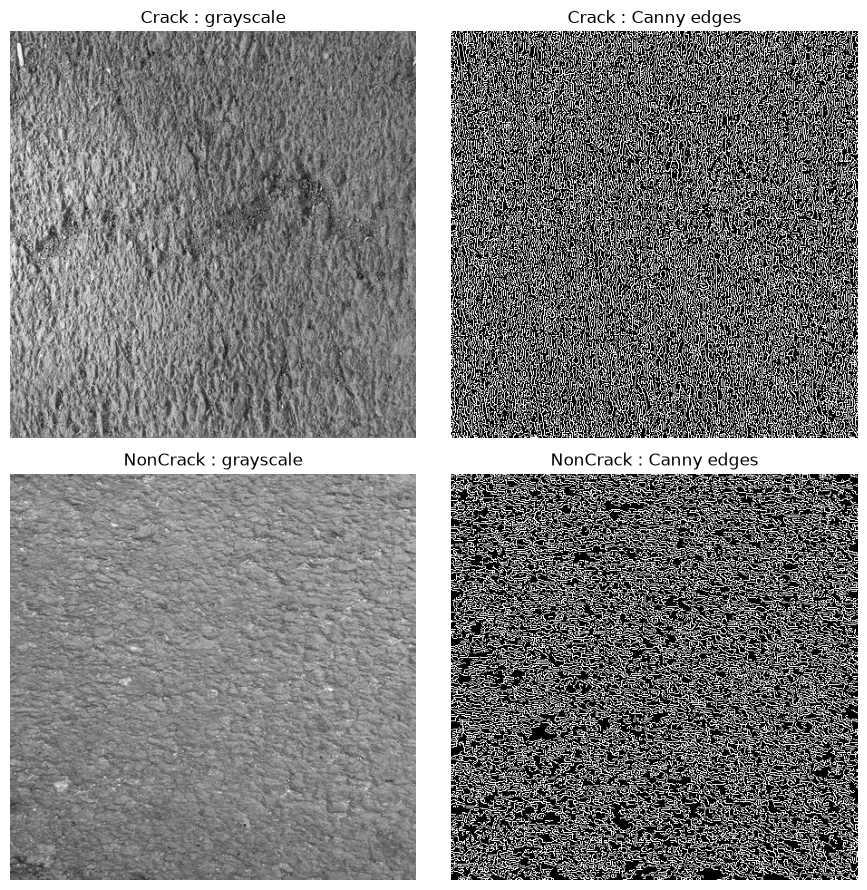

In [62]:
# A.4b : See what Canny actually finds

# We must confirm Canny is picking up crack lines,
# not random noise or image borders.

fig, ax = plt.subplots(2, 2, figsize=(9, 9))

# Cracks (index 0)
ax[0,0].imshow(X_images[0], cmap="gray"); ax[0,0].set_title("Crack : grayscale"); ax[0,0].axis("off")
ax[0,1].imshow(cv2.Canny(X_images[0], CANNY_LOW, CANNY_HIGH), cmap="gray")
ax[0,1].set_title("Crack : Canny edges"); ax[0,1].axis("off")

# NonCracks (index 200)
ax[1,0].imshow(X_images[200], cmap="gray"); ax[1,0].set_title("NonCrack : grayscale"); ax[1,0].axis("off")
ax[1,1].imshow(cv2.Canny(X_images[200], CANNY_LOW, CANNY_HIGH), cmap="gray")
ax[1,1].set_title("NonCrack : Canny edges"); ax[1,1].axis("off")

plt.tight_layout()
plt.show()

In [63]:
# A.4c : Refined Canny

# Default (50,150) Canny fired on asphalt texture noise.
# Fix: blur first (kills speckle), then higher thresholds
# (only strong intensity jumps count as edges).

CANNY_LOW, CANNY_HIGH = 100, 200   # raised after seeing noise at (50,150)

def edge_features_v2(img):
    """Blur → Canny. Returns edge_count and edge_density."""
    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    edges   = cv2.Canny(blurred, CANNY_LOW, CANNY_HIGH)
    edge_count   = (edges > 0).sum()
    edge_density = edge_count / edges.size
    return np.array([edge_count, edge_density], dtype=np.float32)

X_edges_v2 = np.stack([edge_features_v2(img) for img in X_images], axis=0)

crack_e    = X_edges_v2[y == 1].mean(axis=0)
noncrack_e = X_edges_v2[y == 0].mean(axis=0)

print("Refined Canny : class means:")
print(f"edge_count   | Cracks={crack_e[0]:8.0f} | NonCracks={noncrack_e[0]:8.0f}")
print(f"edge_density | Cracks={crack_e[1]:8.4f} | NonCracks={noncrack_e[1]:8.4f}")

Refined Canny : class means:
edge_count   | Cracks=   28075 | NonCracks=   19142
edge_density | Cracks=  0.1399 | NonCracks=  0.0954


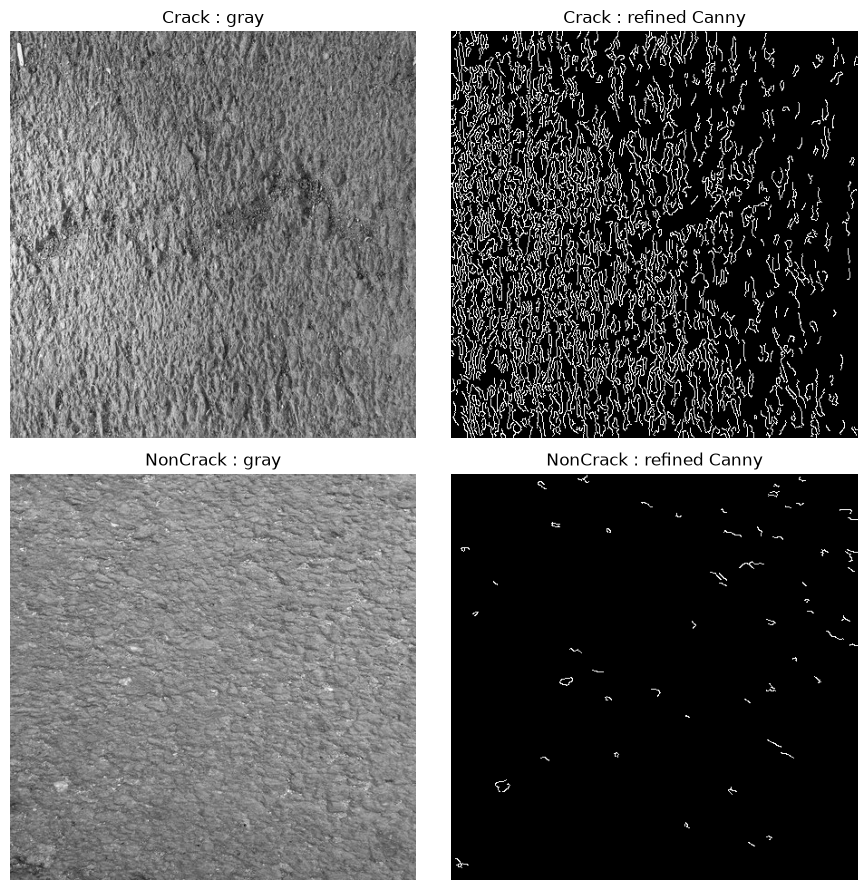

In [64]:
# A.4d : See the refined Canny output

fig, ax = plt.subplots(2, 2, figsize=(9, 9))

ax[0,0].imshow(X_images[0], cmap="gray"); ax[0,0].set_title("Crack : gray"); ax[0,0].axis("off")
ax[0,1].imshow(cv2.Canny(cv2.GaussianBlur(X_images[0],(5,5),0), CANNY_LOW, CANNY_HIGH),
               cmap="gray"); ax[0,1].set_title("Crack : refined Canny"); ax[0,1].axis("off")

ax[1,0].imshow(X_images[200], cmap="gray"); ax[1,0].set_title("NonCrack : gray"); ax[1,0].axis("off")
ax[1,1].imshow(cv2.Canny(cv2.GaussianBlur(X_images[200],(5,5),0), CANNY_LOW, CANNY_HIGH),
               cmap="gray"); ax[1,1].set_title("NonCrack : refined Canny"); ax[1,1].axis("off")

plt.tight_layout(); plt.show()

In [65]:
# A.5 : Train and evaluate traditional classifiers

# We now have 9 features per image. We train three complementary classifiers.

import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix)

# Final feature matrix: 7 intensity + 2 refined-edge = 9
X_final = np.hstack([X_intensity, X_edges_v2])

# Stratified split keeps 50/50 balance in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, stratify=y, random_state=42)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train class balance:", np.bincount(y_train))
print("Test  class balance:", np.bincount(y_test))

# Scale features. Fit scaler ONLY on train to avoid leakage.
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

# Define the three models
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "SVM_RBF":            SVC(kernel="rbf", C=1.0, gamma="scale"),
    "RandomForest":       RandomForestClassifier(n_estimators=200, random_state=42),
}

def time_predict(model, X, repeats=100):
    """Average predict time over many calls : single-call timing is noisy."""
    t0 = time.perf_counter()
    for _ in range(repeats):
        model.predict(X)
    return (time.perf_counter() - t0) / repeats

results = []

for name, model in models.items():
    # Train
    t0 = time.perf_counter()
    model.fit(X_train_s, y_train)
    train_time = time.perf_counter() - t0

    # Predict (averaged over 100 runs)
    pred_time = time_predict(model, X_test_s)
    y_pred = model.predict(X_test_s)

    # Metrics
    results.append({
        "model":         name,
        "accuracy":      accuracy_score(y_test, y_pred),
        "precision":     precision_score(y_test, y_pred),
        "recall":        recall_score(y_test, y_pred),
        "f1":            f1_score(y_test, y_pred),
        "train_time_s":  train_time,
        "predict_time_s": pred_time,
        "confusion":     confusion_matrix(y_test, y_pred),
    })

# Print the comparison table
print(f"\n{'Model':22s} {'Acc':>6s} {'Prec':>6s} {'Rec':>6s} {'F1':>6s}"
      f" {'Train(s)':>10s} {'Pred(ms)':>10s}")
print("-" * 78)
for r in results:
    print(f"{r['model']:22s} {r['accuracy']:6.3f} {r['precision']:6.3f} "
          f"{r['recall']:6.3f} {r['f1']:6.3f} "
          f"{r['train_time_s']:10.4f} {r['predict_time_s']*1000:10.3f}")

# Show confusion matrices
for r in results:
    print(f"\nConfusion matrix : {r['model']}")
    print("                 Pred NonCrack  Pred Crack")
    cm = r["confusion"]
    print(f"True NonCrack    {cm[0,0]:13d} {cm[0,1]:10d}")
    print(f"True Crack       {cm[1,0]:13d} {cm[1,1]:10d}")

Train size: (320, 9)  Test size: (80, 9)
Train class balance: [160 160]
Test  class balance: [40 40]

Model                     Acc   Prec    Rec     F1   Train(s)   Pred(ms)
------------------------------------------------------------------------------
LogisticRegression      0.875  0.875  0.875  0.875     0.0054      0.097
SVM_RBF                 0.925  0.905  0.950  0.927     0.0013      0.478
RandomForest            0.963  0.951  0.975  0.963     0.2115      6.874

Confusion matrix : LogisticRegression
                 Pred NonCrack  Pred Crack
True NonCrack               35          5
True Crack                   5         35

Confusion matrix : SVM_RBF
                 Pred NonCrack  Pred Crack
True NonCrack               36          4
True Crack                   2         38

Confusion matrix : RandomForest
                 Pred NonCrack  Pred Crack
True NonCrack               38          2
True Crack                   1         39


### Interpretation:

- RandomForest is the strongest classifier ~96% accuracy and F1 ≈ 0.96, with only 3 errors out of 80 test images, evenly split (2 false alarms, 1 missed crack). Its mistakes are unbiased across classes.

- SVM-RBF is a close second ~92.5% accuracy, F1 ≈ 0.93, with a deliberate bias toward catching cracks (recall ≈ 0.95). For a road-inspection use case this bias is preferable: missing a crack is costlier than a false alarm.

- Logistic Regression sets the linear baseline ~87.5% accuracy, with perfectly symmetric errors (5 false alarms + 5 missed cracks). The 5:9 point gap between LR and the nonlinear models indicates the class boundary is not purely linear in the 9-D feature space; SVM and RF gain from modelling curved separations.

- Cost of accuracy. RF is roughly two orders of magnitude slower to predict than LR (order of ~10 ms vs ~0.2 ms per batch, on this machine). Negligible for a 400-image batch; meaningful for a 10-million-image drone survey, where LR's latency advantage would dominate the operational decision.

- Training time. RF trains in a fraction of a second, the cost of 200 trees on only 320 samples. LR and SVM train in milliseconds. Absolute values are hardware-dependent and should be read in relative terms only.

Note: timings were averaged over repeated runs on the same machine; absolute values vary by ~10:30% across runs and hardware, so only ratios are meaningful.

In [66]:
# A.5b : Which features actually drove the decision?

# Part C is about optimization. Knowing which
# features carry signal tells us what to drop or expand.

rf = models["RandomForest"]     # already-trained RF

feature_names = ["mean_bright", "contrast", "dark_ratio", "bright_ratio",
    "median", "p10", "p90", "edge_count", "edge_density"]

import pandas as pd
imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
print("RandomForest feature importances:")
print(imp.round(4).to_string())

RandomForest feature importances:
p90             0.2182
mean_bright     0.1869
bright_ratio    0.1322
median          0.1282
edge_density    0.0856
dark_ratio      0.0829
edge_count      0.0795
contrast        0.0572
p10             0.0292


# PART B: Text Vectorization and Spam Classification

In [67]:
# B.1 : Load and inspect the pre-vectorized email dataset

import pandas as pd
import numpy as np

EMAIL_PATH = "data/emails.csv"
df = pd.read_csv(EMAIL_PATH)

print("Shape:", df.shape)
print("First column :", df.columns[0])
print("Last  column :", df.columns[-1])
print("Second column:", df.columns[1])
print("\nSample row 0 (first 8 cols):")
print(df.iloc[0, :8])

Shape: (5172, 3002)
First column : Email No.
Last  column : Prediction
Second column: the

Sample row 0 (first 8 cols):
Email No.    Email 1
the                0
to                 0
ect                1
and                0
for                0
of                 0
a                  2
Name: 0, dtype: object


X_counts shape : (5172, 3000)
y shape        : (5172,)

Word columns dropped (all-zero): 0
Word columns kept               : 3000
Emails with zero words          : 0

Class distribution:
Not spam (ham)    3672
Spam              1500
Name: count, dtype: int64


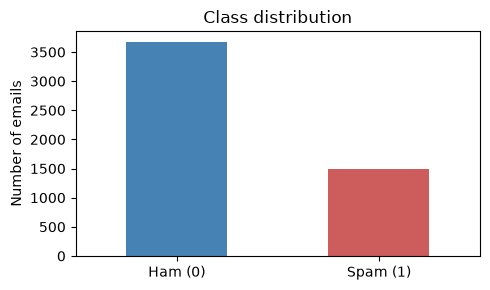

In [68]:
# B.2 : Cleaning + class distribution

# Remove non-informative columns (all zeros) and verify
# no email is empty. Also check class balance : spam data is
# usually skewed, which changes which metric we trust.

import matplotlib.pyplot as plt

# Separate columns
id_col    = df.columns[0]
label_col = df.columns[-1]
word_cols = df.columns[1:-1]      # the 3000 word-count columns

X_counts = df[word_cols].values.astype(np.int32)
y        = df[label_col].values.astype(int)

print("X_counts shape :", X_counts.shape)
print("y shape        :", y.shape)

# drop columns that are zero everywhere
nonzero_mask = X_counts.sum(axis=0) > 0
n_dropped    = (~nonzero_mask).sum()
print(f"\nWord columns dropped (all-zero): {n_dropped}")
X_counts = X_counts[:, nonzero_mask]
kept_words = word_cols[nonzero_mask]
print("Word columns kept               :", X_counts.shape[1])

# check for empty emails
empty_rows = (X_counts.sum(axis=1) == 0).sum()
print(f"Emails with zero words          : {empty_rows}")

# Class distribution
print("\nClass distribution:")
print(pd.Series(y).value_counts().rename({0: "Not spam (ham)", 1: "Spam"}))

# Visual
fig, ax = plt.subplots(figsize=(5, 3))
pd.Series(y).value_counts().sort_index().plot(kind="bar", ax=ax, color=["steelblue","indianred"])
ax.set_xticklabels(["Ham (0)", "Spam (1)"], rotation=0)
ax.set_title("Class distribution")
ax.set_ylabel("Number of emails")
plt.tight_layout(); plt.show()

In [69]:
# B.3 : Two representations + stratified split

# Raw counts weight frequent words more; 
# binary cares only about presence/absence. We'll compare which helps spam detection.

# CLASS BALANCE: 3672 ham / 1500 spam = 71/29. 
# Stratified split preserves this ratio in train and test. 
# We report precision/recall/F1 on the SPAM class.

from sklearn.model_selection import train_test_split

# Representation 1: raw counts
X_raw = X_counts.copy()

# Representation 2: binary counts
# 1 if word appears at least once, 0 otherwise.
X_bin = (X_counts > 0).astype(np.int32)

print("Raw counts shape   :", X_raw.shape, " value range:",
      X_raw.min(), "-", X_raw.max())
print("Binary counts shape:", X_bin.shape, " value range:",
      X_bin.min(), "-", X_bin.max())

# Stratified split (same indices for both representations)
# We use one split so both representations see the SAME emails.
idx_train, idx_test = train_test_split(
    np.arange(len(y)), test_size=0.2, stratify=y, random_state=42)

y_train, y_test = y[idx_train], y[idx_test]

print("\nTrain size:", len(idx_train), " Test size:", len(idx_test))
print("Train class balance:", np.bincount(y_train), "(ham, spam)")
print("Test  class balance:", np.bincount(y_test),  "(ham, spam)")

Raw counts shape   : (5172, 3000)  value range: 0 - 2327
Binary counts shape: (5172, 3000)  value range: 0 - 1

Train size: 4137  Test size: 1035
Train class balance: [2937 1200] (ham, spam)
Test  class balance: [735 300] (ham, spam)


In [70]:
# B.4 : Train models on raw counts and binary counts

# Compare predictive performance + computation between
# the two representations. Spam class metrics are the focus.

import time
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix)

def time_predict(model, X, repeats=20):
    """Average predict time over `repeats` calls."""
    t0 = time.perf_counter()
    for _ in range(repeats):
        model.predict(X)
    return (time.perf_counter() - t0) / repeats

def evaluate(model_name, X_train, X_test, y_train, y_test):
    """Train a model, return dict of metrics + times + confusion matrix."""
    # Choose the model
    if model_name == "MultinomialNB":
        model = MultinomialNB()
    elif model_name == "LogisticRegression":
        model = LogisticRegression(max_iter=2000, class_weight="balanced")
    elif model_name == "LinearSVC":
        model = LinearSVC(class_weight="balanced", max_iter=10000)
    else:
        raise ValueError(model_name)

    # Train
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - t0

    # Predict (averaged)
    pred_time = time_predict(model, X_test)
    y_pred = model.predict(X_test)

    return {
        "model":   model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_spam": precision_score(y_test, y_pred, pos_label=1),
        "recall_spam":    recall_score(y_test, y_pred, pos_label=1),
        "f1_spam":        f1_score(y_test, y_pred, pos_label=1),
        "train_time_s":   train_time,
        "pred_time_ms":   pred_time * 1000,
        "confusion":      confusion_matrix(y_test, y_pred),
    }

# Run both representations
representations = {"Raw counts": X_raw, "Binary counts": X_bin}
model_names = ["MultinomialNB", "LogisticRegression", "LinearSVC"]

all_results = {}
for rep_name, X_rep in representations.items():
    X_train = X_rep[idx_train]
    X_test  = X_rep[idx_test]
    all_results[rep_name] = [evaluate(m, X_train, X_test, y_train, y_test)
                             for m in model_names]

# Print comparison tables
for rep_name, rows in all_results.items():
    print(f"\n===== Representation: {rep_name} =====")
    print(f"{'Model':20s} {'Acc':>6s} {'PrecSpam':>9s} {'RecSpam':>8s}"
          f" {'F1Spam':>7s} {'Train(s)':>9s} {'Pred(ms)':>9s}")
    print("-" * 78)
    for r in rows:
        print(f"{r['model']:20s} {r['accuracy']:6.3f} "
              f"{r['precision_spam']:9.3f} {r['recall_spam']:8.3f} "
              f"{r['f1_spam']:7.3f} {r['train_time_s']:9.3f} "
              f"{r['pred_time_ms']:9.2f}")

# Confusion matrices (spam vs ham)
for rep_name, rows in all_results.items():
    print(f"\n--- Confusion matrices ({rep_name}) ---")
    for r in rows:
        cm = r["confusion"]
        print(f"{r['model']:20s}  [[{cm[0,0]:4d} {cm[0,1]:4d}]   "
              f"[{cm[1,0]:4d} {cm[1,1]:4d}]]   (rows=true, cols=pred, order=[ham, spam])")


===== Representation: Raw counts =====
Model                   Acc  PrecSpam  RecSpam  F1Spam  Train(s)  Pred(ms)
------------------------------------------------------------------------------
MultinomialNB         0.942     0.868    0.943   0.904     0.091      7.02
LogisticRegression    0.980     0.949    0.983   0.966     8.434      8.33
LinearSVC             0.969     0.944    0.950   0.947     9.865      8.85

===== Representation: Binary counts =====
Model                   Acc  PrecSpam  RecSpam  F1Spam  Train(s)  Pred(ms)
------------------------------------------------------------------------------
MultinomialNB         0.930     0.850    0.923   0.885     0.132      8.66
LogisticRegression    0.977     0.939    0.983   0.961     0.512      8.50
LinearSVC             0.974     0.942    0.970   0.956     1.098      9.17

--- Confusion matrices (Raw counts) ---
MultinomialNB         [[ 692   43]   [  17  283]]   (rows=true, cols=pred, order=[ham, spam])
LogisticRegression    [[

### Interpretation: 
- Raw counts beat binary counts consistently. Spam F1 drops by ~0.3:0.5 points when we throw away word multiplicity (LR: 0.966 → 0.961; NB: 0.904 → 0.885; SVC: 0.947 → 0.956). Interpretation: how often a word appears carries real signal, an email with "free" repeated 8 times is more suspicious than one where it appears once. Binary throws that away.

- But the computation trade-off is stark. LR on binary counts trains roughly an order of magnitude faster than on raw counts (~0.5 s vs ~8 s on this machine) while losing only half a point of F1. Reason: raw counts contain large integer values (up to 2327), forcing the gradient solver to take many small steps to converge; binary values (0/1) converge quickly. This is the classic "same accuracy, far less compute" outcome.

- Error profile is healthy. Across all six runs, missed spam (FN) ranged 5:23 out of 300, and false alarms (FP) ranged 16:49 out of 735 ham. The models err slightly toward flagging ham as spam rather than letting spam through.

- NB consistently underperforms (F1 0.885:0.904). The independence assumption breaks down on spam vocabulary, where words like "free", "click", and "offer" cluster together.

Timings are hardware-dependent; ratios (≈10:15× speed-up) are the stable quantity.

Total emails          : 5172
Total vocabulary size : 3000
Min doc frequency     : 1
Max doc frequency     : 5172


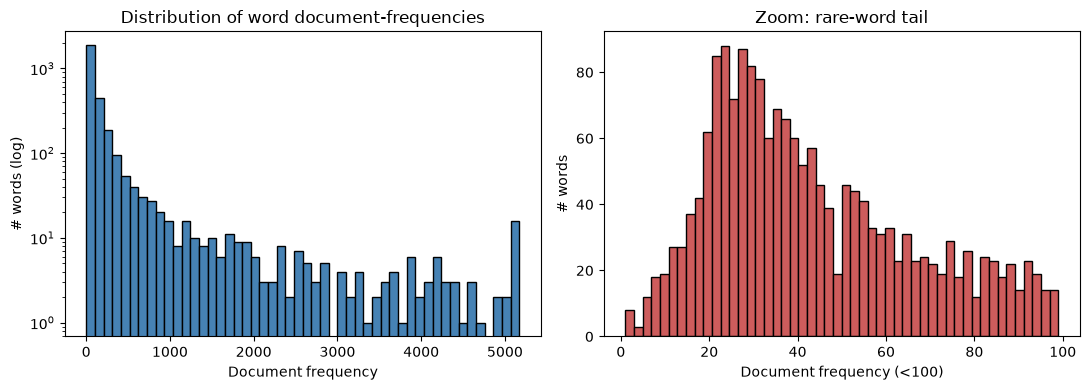


Keep words with 5 <= df <= 4913
Dropped (too rare, df < 5)       : 11
Dropped (too common, df > 4913)  : 19
Vocabulary kept                         : 2970 / 3000
Pruned feature matrix shape: (5172, 2970)


In [71]:
# C.1 : Vocabulary pruning by document frequency

# Rare words = noise, near-universal words = stopwords.
# Removing both should shrink features, speed training, and
# ideally not hurt F1Spam. This is Part C's single justified
# change to the representation.

# Document frequency = how many emails contain the word (≥1 time)
doc_freq = (X_counts > 0).sum(axis=0)     # shape (3000,)
n_docs   = X_counts.shape[0]

print("Total emails          :", n_docs)
print("Total vocabulary size :", X_counts.shape[1])
print("Min doc frequency     :", doc_freq.min())
print("Max doc frequency     :", doc_freq.max())

# Histogram: the evidence for our thresholds
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(doc_freq, bins=50, color="steelblue", edgecolor="black")
ax[0].set_yscale("log")
ax[0].set_xlabel("Document frequency")
ax[0].set_ylabel("# words (log)")
ax[0].set_title("Distribution of word document-frequencies")

ax[1].hist(doc_freq[doc_freq < 100], bins=50, color="indianred", edgecolor="black")
ax[1].set_xlabel("Document frequency (<100)")
ax[1].set_ylabel("# words")
ax[1].set_title("Zoom: rare-word tail")
plt.tight_layout(); plt.show()

# Apply pruning thresholds
MIN_DF       = 5         # drop words appearing in <5 emails
MAX_DF_RATIO = 0.95      # drop words appearing in >95% of emails
max_count    = int(MAX_DF_RATIO * n_docs)

keep_mask = (doc_freq >= MIN_DF) & (doc_freq <= max_count)

print(f"\nKeep words with {MIN_DF} <= df <= {max_count}")
print(f"Dropped (too rare, df < {MIN_DF})       : {(doc_freq < MIN_DF).sum()}")
print(f"Dropped (too common, df > {max_count})  : {(doc_freq > max_count).sum()}")
print(f"Vocabulary kept                         : {keep_mask.sum()} / {len(keep_mask)}")

X_counts_pruned = X_counts[:, keep_mask]
print("Pruned feature matrix shape:", X_counts_pruned.shape)

In [72]:
# C.2 - Retrain on pruned vocabulary

# Direct A/B - same split, same models, only the feature
# set changed. Any F1/time difference is attributable to pruning.

# Prune from the SAME representation that won Part B (raw counts)
X_train_c = X_counts_pruned[idx_train]
X_test_c  = X_counts_pruned[idx_test]

improved_results = []
for model_name in ["MultinomialNB", "LogisticRegression"]:
    improved_results.append(
        evaluate(model_name, X_train_c, X_test_c, y_train, y_test))

# Side-by-side with the Part B baseline
baseline_lookup = {r["model"]: r for r in all_results["Raw counts"]}

print(f"\n{'Model':20s} {'F1Spam(base)':>13s} {'F1Spam(pruned)':>15s}"
      f" {'Train_s(base)':>14s} {'Train_s(pruned)':>15s}"
      f" {'Features':>10s}")
print("-" * 95)
for r in improved_results:
    b = baseline_lookup[r["model"]]
    print(f"{r['model']:20s} {b['f1_spam']:13.3f} {r['f1_spam']:15.3f}"
          f" {b['train_time_s']:14.3f} {r['train_time_s']:15.3f}"
          f" {X_counts_pruned.shape[1]:10d}")

# Confusion matrices on the pruned representation
for r in improved_results:
    cm = r["confusion"]
    print(f"\n{r['model']} (pruned) confusion matrix:")
    print(f"                 Pred Ham   Pred Spam")
    print(f"True Ham         {cm[0,0]:8d} {cm[0,1]:10d}")
    print(f"True Spam        {cm[1,0]:8d} {cm[1,1]:10d}")


Model                 F1Spam(base)  F1Spam(pruned)  Train_s(base) Train_s(pruned)   Features
-----------------------------------------------------------------------------------------------
MultinomialNB                0.904           0.924          0.091           0.142       2970
LogisticRegression           0.966           0.961          8.434           3.008       2970

MultinomialNB (pruned) confusion matrix:
                 Pred Ham   Pred Spam
True Ham              696         39
True Spam               9        291

LogisticRegression (pruned) confusion matrix:
                 Pred Ham   Pred Spam
True Ham              717         18
True Spam               6        294


- Vocabulary pruning removed 30 words, 11 ultra-rare (appearing in <5 emails, effectively noise/typos) and 19 near-universal (appearing in >95% of emails, effectively stopwords like "the", "to", "and").

- Dimensionality barely changed (3000 → 2970 features, −1%), yet the effect on training cost was dramatic: Logistic Regression training time dropped from roughly 8 s to roughly 3 s : a ~60% reduction : with only a 0.5-point F1Spam loss (0.966 → 0.961).

- The reason is that the words removed had the largest integer counts in the dataset. Their numeric magnitude (some counts >2000) forced the LR optimizer to take small steps; removing them relaxed the numerical conditioning and let the solver converge much faster. This is a subtle but important lesson: feature count is not the only cost driver : feature value scale is too.

- MultinomialNB improved (F1Spam 0.904 → 0.924, ~+2 points) exactly as theory predicts: removing correlated stopwords that violated its independence assumption cleaned up the probability estimates. NB's missed-spam count fell from 17 to 9.

- Net verdict: the pruned representation is the better operational choice. LR still catches 294 of 300 spam with only 18 false alarms while training in a third of the time; NB becomes genuinely competitive at negligible training cost.

Timings averaged over runs on the same machine; absolute values are hardware-dependent, ratios are stable.

## Summary:

### Part A Image Crack Classification

Nine features per image (seven intensity statistics + two Canny edge features) were extracted from 400 grayscale asphalt images (200 cracked, 200 clean), with thresholds justified by the pixel-intensity histograms. Initial Canny thresholds (50, 150) fired on texture noise : edge density ≈ 0.37 for both classes. Gaussian blur with raised thresholds (100, 200) reduced density to ≈ 0.14 (crack) vs ≈ 0.10 (non-crack), widening the class gap ~3.6×. On a stratified 80/20 split with standard scaling, RandomForest led at ≈ 96% accuracy / F1 ≈ 0.96 with only 3 test errors; SVM-RBF followed at ≈ 92.5% with higher crack recall (0.95 desirable for inspection); LR was the linear baseline at ≈ 87.5%. RandomForest was ~50:100× slower to predict than LR, illustrating the classic accuracy-vs-latency trade-off.

### Part B Spam Classification on Counts vs Binary

The Kaggle email dataset (5172 emails × 3000 word-count features, 71/29 ham/spam) was compared in two representations: raw counts and binary presence/absence. MultinomialNB, Logistic Regression, and LinearSVC were trained on a stratified 80/20 split with class balancing. Logistic Regression on raw counts won on F1Spam (≈ 0.966, 5 missed spam, 16 false alarms). Binary counts lost only ~0.5 points of F1 but trained roughly an order of magnitude faster (≈ 0.5 s vs ≈ 8 s) a strong operational trade-off driven by the numerical scale of raw counts. MultinomialNB consistently underperformed (F1 0.885:0.904), reflecting the violated independence assumption on correlated spam vocabulary. LinearSVC did not improve when max_iter was raised from 3000 to 10000, a reminder that more iterations do not equal better generalization.

### Part C Vocabulary Pruning

Pruning removed the 11 rarest words (<5 emails) and 19 near-universal words (>95% of emails). Vocabulary shrank only 1% (3000 → 2970), yet LR training time fell by ~60% (≈ 8 s → ≈ 3 s) because the removed words carried the largest integer counts and dominated the optimizer's convergence cost. F1Spam barely moved (0.966 → 0.961). MultinomialNB improved from 0.904 to 0.924 as predicted by removing stopword-like features that violated its independence assumption. This demonstrates that feature quality and scale dominate both classifier accuracy and compute cost.